# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [16]:
# Import the library
from PIL import Image
import matplotlib.pyplot as plt


--2026-04-21 14:48:13--  https://raw.githubusercontent.com/hebaOrhb/03-ImageProcessing-lab3/master/cameraman.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28210 (28K) [image/jpeg]
Saving to: ‘cameraman.jpg’

cameraman.jpg       100%[===================>]  27.55K  --.-KB/s    in 0.001s  

2026-04-21 14:48:13 (25.5 MB/s) - ‘cameraman.jpg’ saved [28210/28210]



(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

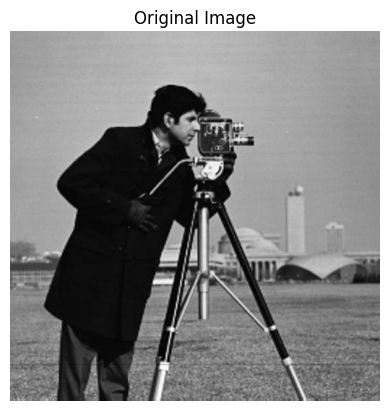

In [22]:
# --- Load image ----------------------------

!wget https://raw.githubusercontent.com/hebaOrhb/03-ImageProcessing-lab3/master/cameraman.jpg

# Open the image
img = Image.open("cameraman.jpg")

# Display the image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [24]:
# Get the size of the image

width, height = img.size

# scaling factors
scale_x = 2
scale_y = 2

In [25]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((width * scale_x, height * scale_y))


Original size: (512, 512)
Scaled size: (1024, 1024)


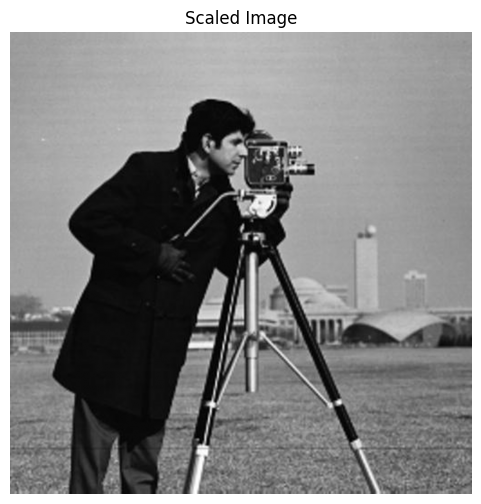

In [26]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

plt.figure(figsize=(6,6))
plt.imshow(scaled_img, cmap='gray')
plt.title("Scaled Image")
plt.axis('off');


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

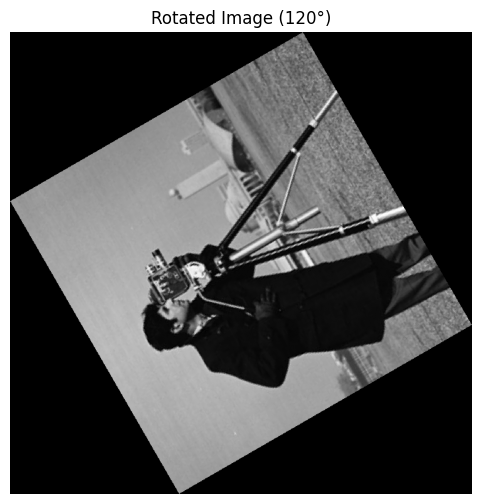

In [27]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")


rotated_img = img.rotate(120, expand=True)

# Save the rotated image
rotated_img.save("task1_2_rotated.jpg")

# Display
plt.figure(figsize=(6,6))
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (120°)")
plt.axis('off');

### 3. Shear

In [29]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [31]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5   # تقدر تغيريه (0.3 / 0.7)

# Shear in X-direction
shx = shear_factor
shy = 0


In [32]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]


sheared_img = img.transform(
    (width + int(shx * height), height),   # new size
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0)
)


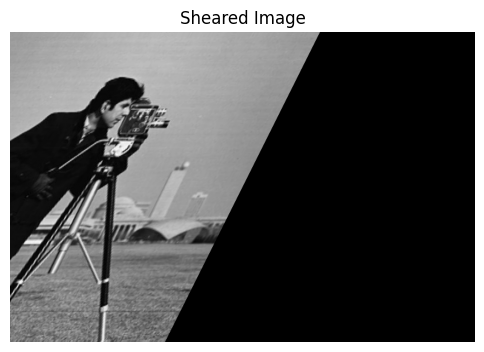

In [33]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
# --- f. Save the sheared image ----------------

sheared_img.save("task1_3_sheared.jpg")

plt.figure(figsize=(6,6))
plt.imshow(sheared_img, cmap='gray')
plt.title("Sheared Image")
plt.axis('off');

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

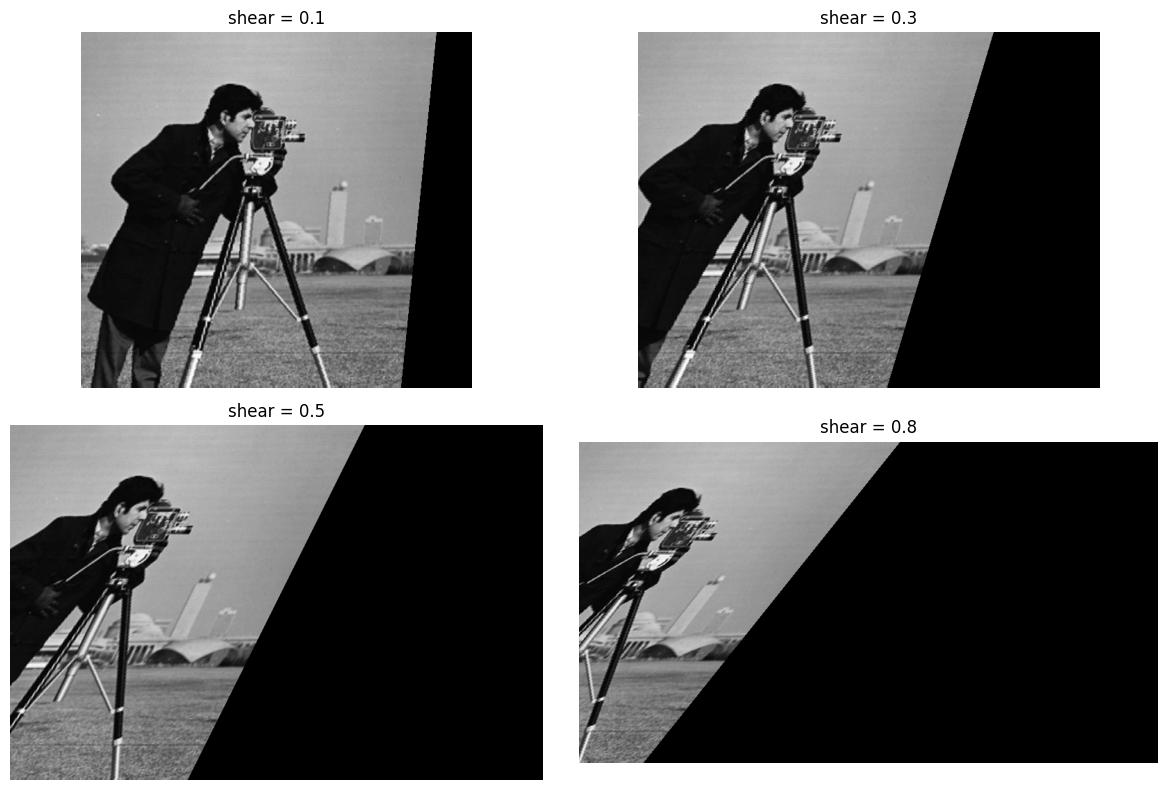

In [36]:
# Compare different shear factors

factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(12,8))

for i, f in enumerate(factors):
    shx = f

    sheared = img.transform(
        (width + int(shx * height), height),
        Image.AFFINE,
        (1, shx, 0,
         0, 1, 0)
    )

    plt.subplot(2,2,i+1)
    plt.imshow(sheared, cmap='gray')
    plt.title(f"shear = {f}")
    plt.axis('off')

plt.tight_layout()

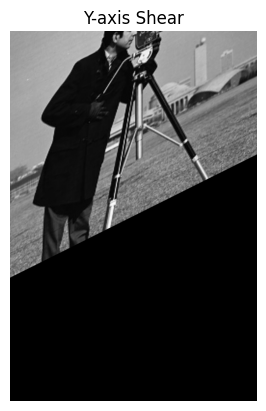

In [37]:
# Y-axis shear

shy = 0.5

sheared_y = img.transform(
    (width, height + int(shy * width)),
    Image.AFFINE,
    (1, 0, 0,
     shy, 1, 0)
)

plt.imshow(sheared_y, cmap='gray')
plt.title("Y-axis Shear")
plt.axis('off');

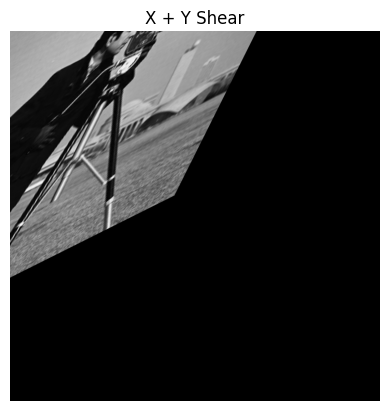

In [38]:
# Combine X and Y shear

shx = 0.5
shy = 0.5

sheared_xy = img.transform(
    (width + int(shx * height), height + int(shy * width)),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0)
)

plt.imshow(sheared_xy, cmap='gray')
plt.title("X + Y Shear")
plt.axis('off');

# Intensity Transformations
Negative · Log · Power Law (Gamma)

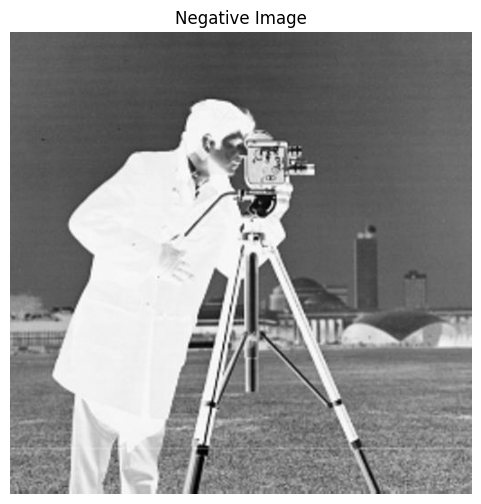

In [35]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

import numpy as np
img_array = np.array(img)

negative_img = 255 - img_array

negative_img_pil = Image.fromarray(negative_img.astype(np.uint8))

negative_img_pil.save("task2_1_negative.jpg")

# Display
plt.figure(figsize=(6,6))
plt.imshow(negative_img_pil, cmap='gray')
plt.title("Negative Image")
plt.axis('off');




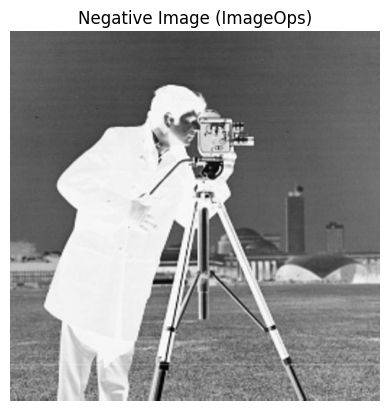

In [39]:
# Method 2: PIL's ImageOps
# Method 2: PIL's ImageOps

from PIL import ImageOps

# Apply negative using ImageOps
negative_img2 = ImageOps.invert(img)

# Save
negative_img2.save("task2_1_negative_method2.jpg")

# Display
plt.imshow(negative_img2, cmap='gray')
plt.title("Negative Image (ImageOps)")
plt.axis('off');

/tmp/ipykernel_14863/1244392896.py:17: RuntimeWarning: divide by zero encountered in log
  log_transformed = c * np.log(1 + arr)
/tmp/ipykernel_14863/1244392896.py:19: RuntimeWarning: invalid value encountered in cast
  log_img = Image.fromarray(np.uint8(log_transformed))


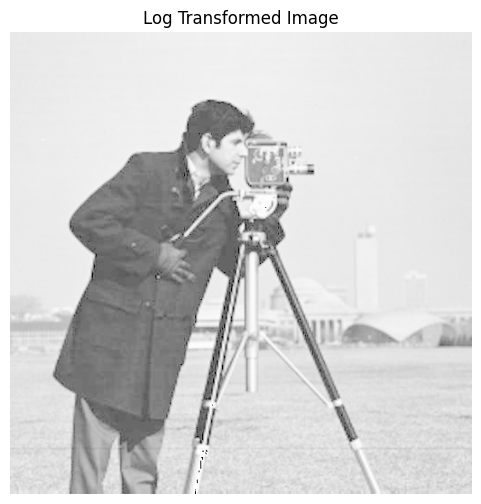

In [40]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel


arr = np.array(img)

c = 255 / np.log(1 + 255)

log_transformed = c * np.log(1 + arr)

log_img = Image.fromarray(np.uint8(log_transformed))

log_img.save("task2_2_log.jpg")

# Display
plt.figure(figsize=(6,6))
plt.imshow(log_img, cmap='gray')
plt.title("Log Transformed Image")
plt.axis('off');

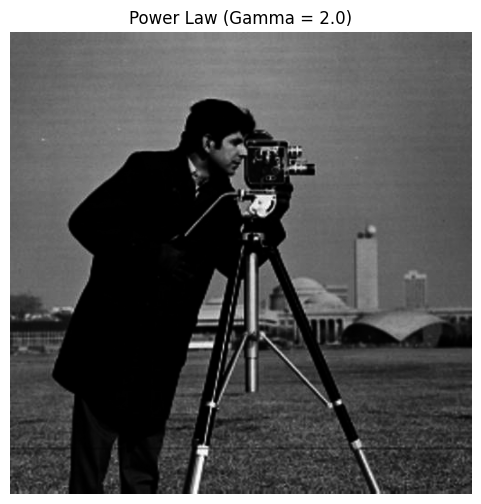

In [41]:

# ── 3. Power-law / Gamma correction ───────────────

arr = np.array(img)

arr_norm = arr / 255.0

gamma = 2.0

power_transformed = np.power(arr_norm, gamma)

power_img = np.uint8(power_transformed * 255)

power_img_pil = Image.fromarray(power_img)

# Save
power_img_pil.save("task2_3_power.jpg")

# Display
plt.figure(figsize=(6,6))
plt.imshow(power_img_pil, cmap='gray')
plt.title(f"Power Law (Gamma = {gamma})")
plt.axis('off');